In [1]:
''' 
Phần 1: tháo tác cơ bản 
Bước 1:  Xử lý cơ bản 
1. Xác định số lượng yếu tố (biến số) tham gia vào yêu cầu 
2. Thu thập dữ liệu (data collection) 
3. Tổng quan dữ liệu VD: df.info()... 
4. Xử lý cơ bản: 
    - Loại bỏ dòng rỗng 
    - Loại bỏ dòng trùng 
    - Khảo sát dữ liệu thiếu 
    - Xử lý dữ liệu thiếu 
5. Kiểm tra lại dữ liệu     
''' 
 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
#Đọc file  
df = pd.read_csv('dulieuxettuyendaihoc.csv',header=0,delimiter=',',encoding='utf-8') 


In [2]:
#Đọc 5 dòng dữ liệu đầu tiên 
df.head(5) 

,MSSV,T1,T2,T3,T4,T5,T6,GT,DT,KV,NGONNGU,TOANLOGICPHANTICH,GIAIQUYETVANDE,KT,NGAYTHI,DINHHUONGNGHENGHIEP
0,SV001,7.2,8.4,7.4,7.2,7.4,6.9,F,NaN,2NT,3.25,3.25,4.50,A1,12/7/2018,No
1,SV002,5.4,6.3,4.3,4.9,3.0,4.0,M,NaN,1,6.00,4.00,3.50,C,12/7/2018,Yes
2,SV003,5.6,5.0,2.8,6.1,4.8,5.7,M,NaN,1,5.00,6.75,4.00,C,12/7/2018,No
3,SV004,6.6,5.1,5.9,4.1,6.1,7.4,M,NaN,1,4.25,4.25,5.25,D1,12/7/2018,No
4,SV005,6.0,5.4,7.6,4.4,6.8,8.0,M,NaN,2NT,4.25,4.50,5.00,A,12/7/2018,No


In [3]:
#Xem thông tin tổng quan 
df.info() 
# Tổng quan dữ liệu 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MSSV                 100 non-null    object 
 1   T1                   100 non-null    float64
 2   T2                   100 non-null    float64
 3   T3                   100 non-null    float64
 4   T4                   100 non-null    float64
 5   T5                   100 non-null    float64
 6   T6                   100 non-null    float64
 7   GT                   100 non-null    object 
 8   DT                   3 non-null      float64
 9   KV                   100 non-null    object 
 10  NGONNGU              100 non-null    float64
 11  TOANLOGICPHANTICH    100 non-null    float64
 12  GIAIQUYETVANDE       100 non-null    float64
 13  KT                   100 non-null    object 
 14  NGAYTHI              100 non-null    object 
 15  DINHHUONGNGHENGHIEP  100 non-null    obje

In [4]:
#Lấy  thông tin các cột  
df = df[['T5','T6','GT','DT','KV','KT','NGONNGU','TOANLOGICPHANTICH', 
'GIAIQUYETVANDE','NGAYTHI','DINHHUONGNGHENGHIEP']] 

In [6]:
#  Đổi tên cột 
df.rename(columns={'TOANLOGICPHANTICH':'LOGIC','GIAIQUYETVANDE':'UNG XU', 
'DINHHUONGNGHENGHIEP':'HUONGNGHIEP'},inplace=True) 
df.head(5)

,T5,T6,GT,DT,KV,KT,NGONNGU,LOGIC,UNG XU,NGAYTHI,HUONGNGHIEP
0,7.4,6.9,F,NaN,2NT,A1,3.25,3.25,4.50,12/7/2018,No
1,3.0,4.0,M,NaN,1,C,6.00,4.00,3.50,12/7/2018,Yes
2,4.8,5.7,M,NaN,1,C,5.00,6.75,4.00,12/7/2018,No
3,6.1,7.4,M,NaN,1,D1,4.25,4.25,5.25,12/7/2018,No
4,6.8,8.0,M,NaN,2NT,A,4.25,4.50,5.00,12/7/2018,No


In [7]:
#Xóa bỏ các dòng dữ liệu rỗng 
df.dropna(how='all',inplace=True)

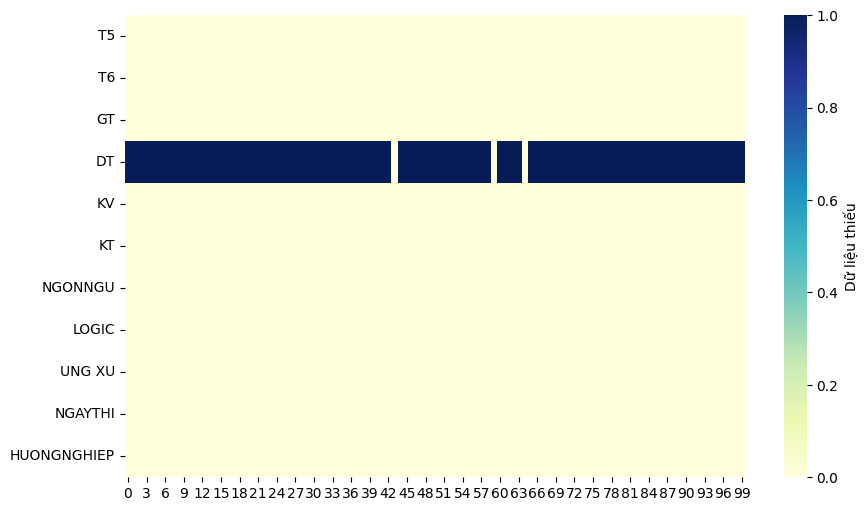

In [8]:
# dùng heatmap để trực quan dữ liệu bị thiếu 
plt.figure(figsize=(10,6)) 
sns.heatmap(df.isna().transpose(),cmap='YlGnBu', 
cbar_kws={'label':'Dữ liệu thiếu'}) 
plt.savefig('missingdata.png',dpi=100) 
# "Note: Với dữ liệu bị thiếu:  
# 1. Cần xác định biến số nào bị thiếu 
# 2. Mức độ thiếu dữ liệu 
# 3. Có cần phải xử lý không"


In [9]:
# Điền giá trị thiếu 
df['DT'].fillna('KINH',inplace=True) 
# Lưu ý: Với biến định tính ta có thể thay bằng giá trị yếu vị (mode) 
# df['DT].fillna(df['DT'].mode()[0],inplace=True) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_11224\3545329148.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'KINH' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['DT'].fillna('KINH',inplace=True)


In [11]:
# Điền thiếu giá trị phần NGONNGU bằng 0 (nếu có) 
df['NGONNGU'].fillna(0,inplace=True) 
# Điền thiếu giá trị phần LOGIC bằng trung bình (nếu có) 
df['LOGIC'].fillna(df['LOGIC'].mean(), inplace=True) 
# Điền thiếu giá trị phần UNGXU bằng trung vị (nếu có) 
df['UNG XU'].fillna(df['UNG XU'].median(),inplace=True) 
# Lưu ý: Với biến định lượng thì ta nên thay bằng trung vị 
 
df.head(5)

,T5,T6,GT,DT,KV,KT,NGONNGU,LOGIC,UNG XU,NGAYTHI,HUONGNGHIEP
0,7.4,6.9,F,KINH,2NT,A1,3.25,3.25,4.50,12/7/2018,No
1,3.0,4.0,M,KINH,1,C,6.00,4.00,3.50,12/7/2018,Yes
2,4.8,5.7,M,KINH,1,C,5.00,6.75,4.00,12/7/2018,No
3,6.1,7.4,M,KINH,1,D1,4.25,4.25,5.25,12/7/2018,No
4,6.8,8.0,M,KINH,2NT,A,4.25,4.50,5.00,12/7/2018,No


In [12]:
''' 
Phần 2: Kỹ thuật Feature Engineering (thường dùng cho Machine Learning) 
Nếu chỉ là xử lý phân tích dữ liệu thì ta gọi là New Attribute 
 
Đây là kỹ thuật tạo thêm hoặc biến đổi số liệu sẵn có thành các biến số mới phù hợp với 
nghiệp vụ 
để phân tích 
Tạo biến TBTOAN: trung bình toán lớp 12 
''' 
df['TBTOAN'] = (df['T5']+df['T6'])/2 
df.head(5) 

,T5,T6,GT,DT,KV,KT,NGONNGU,LOGIC,UNG XU,NGAYTHI,HUONGNGHIEP,TBTOAN
0,7.4,6.9,F,KINH,2NT,A1,3.25,3.25,4.50,12/7/2018,No,7.15
1,3.0,4.0,M,KINH,1,C,6.00,4.00,3.50,12/7/2018,Yes,3.50
2,4.8,5.7,M,KINH,1,C,5.00,6.75,4.00,12/7/2018,No,5.25
3,6.1,7.4,M,KINH,1,D1,4.25,4.25,5.25,12/7/2018,No,6.75
4,6.8,8.0,M,KINH,2NT,A,4.25,4.50,5.00,12/7/2018,No,7.40


In [13]:
# Tạo biến XEPLOAI: đánh giá môn toán dựa trên df['TBTOAN'] 
df.loc[df['TBTOAN'] < 5.0, 'XEPLOAI'] = 'FAIL' 
df.loc[(df['TBTOAN'] >= 5.0) & (df['TBTOAN'] < 7.0) , 'XEPLOAI'] = 'FAIR' 
df.loc[(df['TBTOAN'] >= 7.0) & (df['TBTOAN'] < 9.0) , 'XEPLOAI'] = 'GOOD' 
df.loc[(df['TBTOAN'] >= 9.0), 'XEPLOAI'] = 'EXCEL' 
df.head(5) 

,T5,T6,GT,DT,KV,KT,NGONNGU,LOGIC,UNG XU,NGAYTHI,HUONGNGHIEP,TBTOAN,XEPLOAI
0,7.4,6.9,F,KINH,2NT,A1,3.25,3.25,4.50,12/7/2018,No,7.15,GOOD
1,3.0,4.0,M,KINH,1,C,6.00,4.00,3.50,12/7/2018,Yes,3.50,FAIL
2,4.8,5.7,M,KINH,1,C,5.00,6.75,4.00,12/7/2018,No,5.25,FAIR
3,6.1,7.4,M,KINH,1,D1,4.25,4.25,5.25,12/7/2018,No,6.75,FAIR
4,6.8,8.0,M,KINH,2NT,A,4.25,4.50,5.00,12/7/2018,No,7.40,GOOD


In [14]:
#Xem thông tin 5 dòng đầu gồm các cột TBTOAN, XEPLOAI 
df[['TBTOAN','XEPLOAI']].head(5)

,TBTOAN,XEPLOAI
0,7.15,GOOD
1,3.50,FAIL
2,5.25,FAIR
3,6.75,FAIR
4,7.40,GOOD


In [15]:
''' 
Tạo biến nhóm khối thi NHOMKT thõa mãn 
A1: G1 
C: G3 
D1: G3 
A: G1 
B: G2 
''' 
dict_map = {'A1':'G1','C':'G3','D1':'G3','A':'G1','B':'G2'} 
df['NHOMKT'] = df['KT'].map(dict_map) 
 
df[['KT','NHOMKT']].head(5)

,KT,NHOMKT
0,A1,G1
1,C,G3
2,C,G3
3,D1,G3
4,A,G1


In [16]:
'''BỮA SAU ngày 25/9 
Tạo biến số điểm cộng: CONG 
Nếu khối thi thuộc nhóm G1, G2 và TBTOAN >= 5.0 thì là 1.0 
Ngược lại thì là 0.0 
''' 
def fplus(x,y): 
    if(x == 'G1' or x == 'G2') and (y>=5.0): 
        return 1.0 
    else: 
        return 0.0 
df['CONG'] = list(map(fplus,df['NHOMKT'],df['TBTOAN'])) 
 
df[['TBTOAN','NHOMKT','CONG']].head(5)

,TBTOAN,NHOMKT,CONG
0,7.15,G1,1.0
1,3.50,G3,0.0
2,5.25,G3,0.0
3,6.75,G3,0.0
4,7.40,G1,1.0


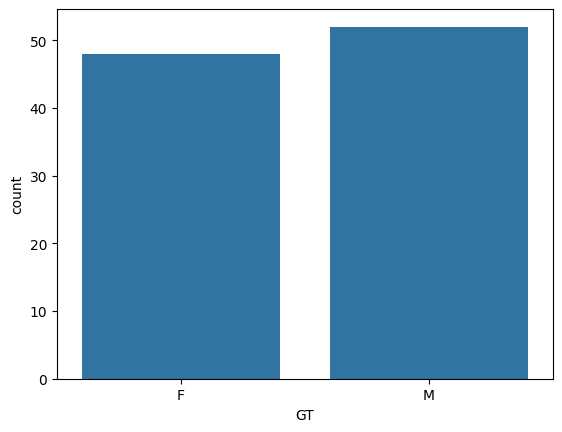

In [17]:
#Phần 3: Trực quan hóa dữ liệu 
''' 
Để trực quan số liệu ta cần lưu ý: Mục đích, sự phối hợp giữa các loại biến để chọn lựa 
biểu đồ phù hợp đi kèm số liệu  
trực quan 
Định tính: bar, pie
Định lượng: line , histogram, box-plot, scatter 
''' 
''' 
Hãy trực quan số lượng học sinh theo giới tính 
''' 
# Biểu đồ bar 
sns.countplot(x='GT', data=df) 
plt.show()

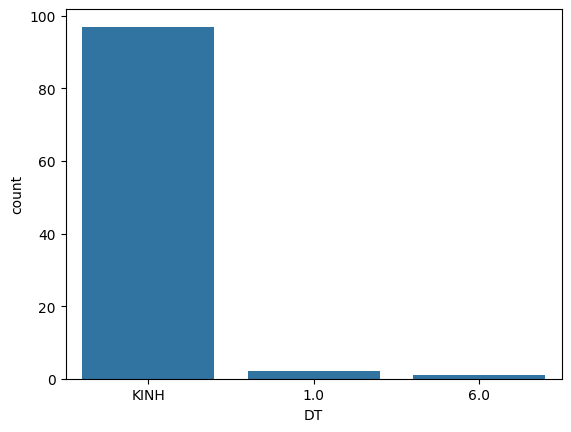

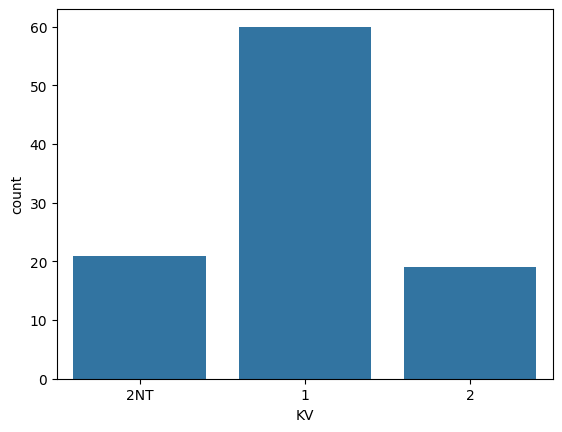

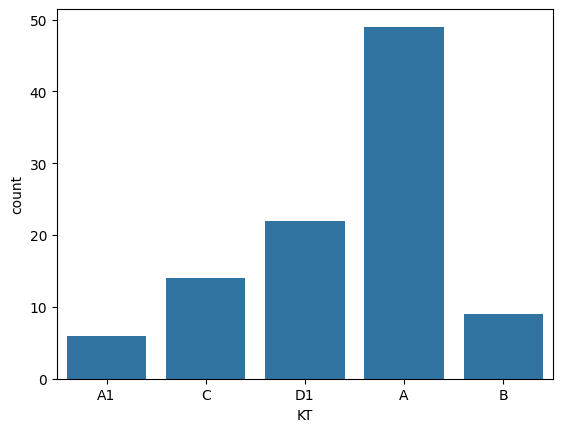

In [18]:
# Lưu ý 
# Các biến dùng để phân nhóm, gom nhóm thông thường là biến định tính và nằm ở các 
# thang đo mức 1,2,3,4 
# tương ứng định danh, phân loại, thứ bậc và khoảng 
 
# Dựa trên biểu đồ DT cho biết tạo sao ta không phân tích theo nhóm DT : vì đa số là dân 
# tộc kinh 
# Tương tự cho các cột KV, DT, KT 
#DT 
sns.countplot(x='DT', data=df) 
plt.show() 
 
sns.countplot(x='KV', data=df) 
plt.show() 
 
sns.countplot(x='KT', data=df) 
plt.show()

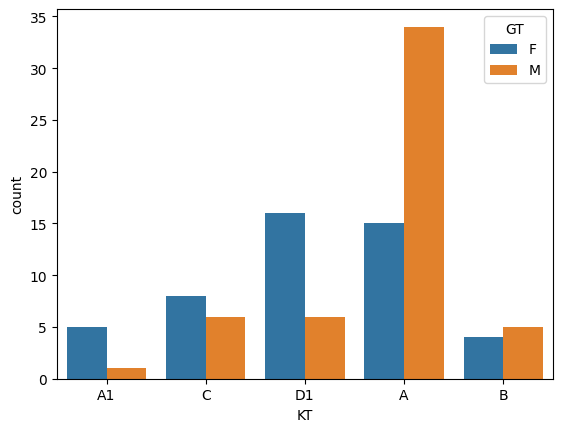

In [19]:
''' 
Hãy so sánh số lượng học sinh đăng ký khối thi dựa trên nhóm giới tính 
''' 
sns.countplot(x='KT',hue='GT',data=df) 
plt.show()

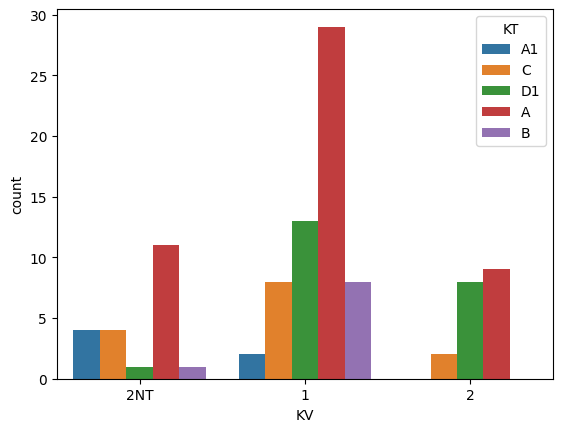

In [20]:
''' 
Làm tương tự cho các nhóm biến định tính (KV,KT) 
Hãy cho biết khối A có sinh viên khu vực nào đăng ký cao nhất 
Trả lời: KV1 
''' 
sns.countplot(x='KV',hue='KT',data=df) 
plt.show() 

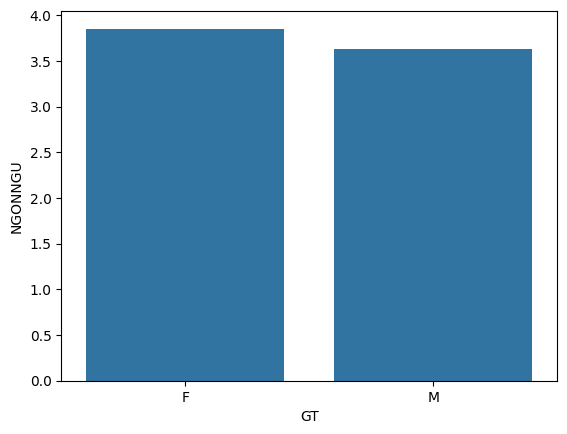

In [21]:
''' 
Hãy so sánh điểm trung bình NGONNGU theo nhóm giới tính 
''' 
sns.barplot(x='GT',y='NGONNGU',data=df,errorbar=None) 
plt.show()

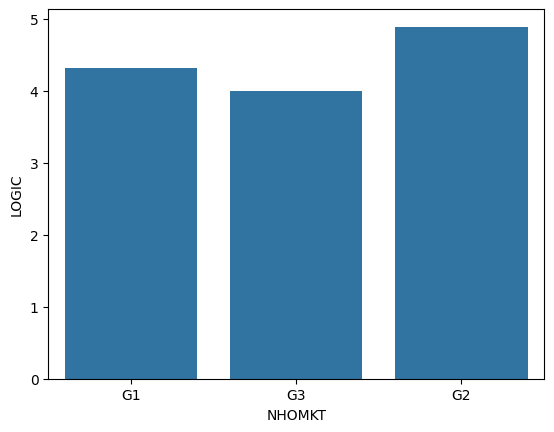

In [22]:
# Hãy so sánh điểm LOGIC theo nhóm KT (nhóm khối thi) 
sns.barplot(x='NHOMKT',y='LOGIC',data=df,errorbar=None) 
plt.show()

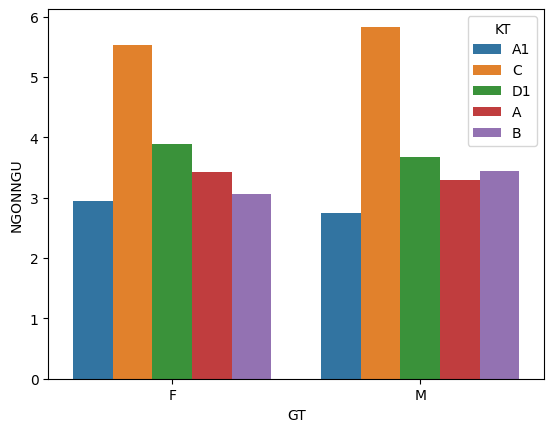

In [23]:
''' 
So sánh điểm trung bình của NGONNGU theo nhóm GT dựa trên KT 
''' 
sns.barplot(x='GT',y='NGONNGU',hue='KT',data=df,errorbar=None) 
plt.show() 

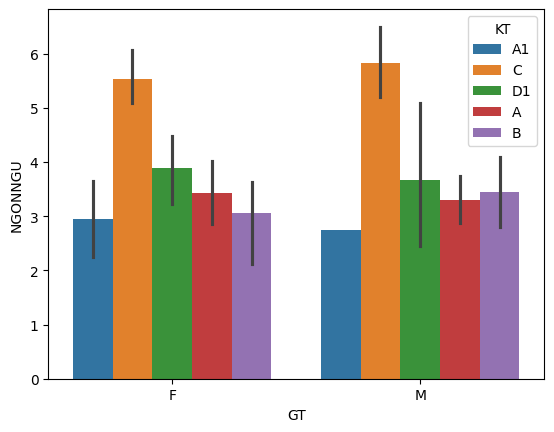

In [24]:
# So sánh sai số trên NGONNGU theo nhóm GT theo KT 
# Sai số càng cao độ tin cậy càng thấp 
sns.barplot(x='GT',y='NGONNGU',hue='KT',data=df) 
plt.show()

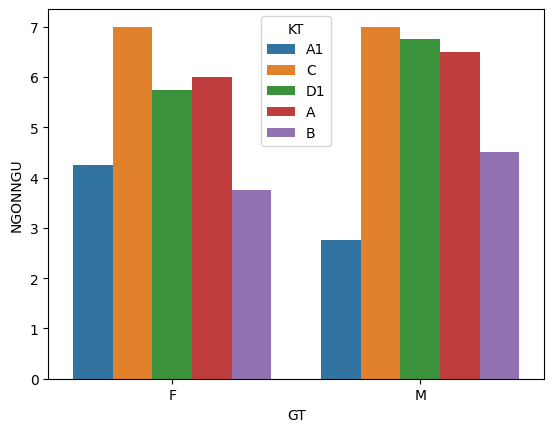

In [25]:
'''
So sánh điểm cao nhất của NGONNGU theo nhóm GT theo KT 
Lưu ý: không để estimator thì mặc định là mean 
estimator: count, min max sum std, mean (default) 
''' 
sns.barplot(x='GT',y='NGONNGU',hue='KT',data=df,errorbar=None,estimator=max) 
plt.show()

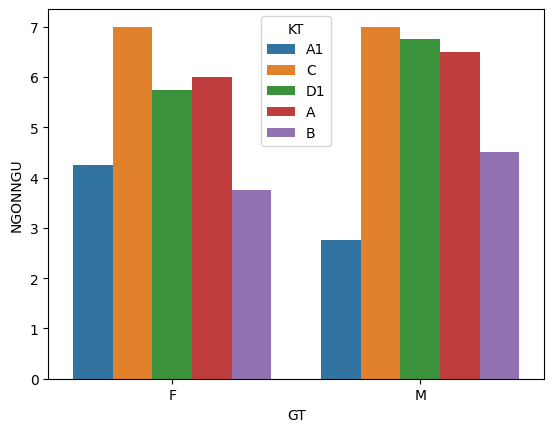

In [26]:
''' 
So sánh điểm cao nhất của NGONNGU theo nhóm GT theo KT
Lưu ý: không để estimator thì mặc định là mean 
estimator: count, min max sum std, mean (default) 
''' 
sns.barplot(x='GT',y='NGONNGU',hue='KT',data=df,errorbar=None,estimator=max) 
plt.show() 

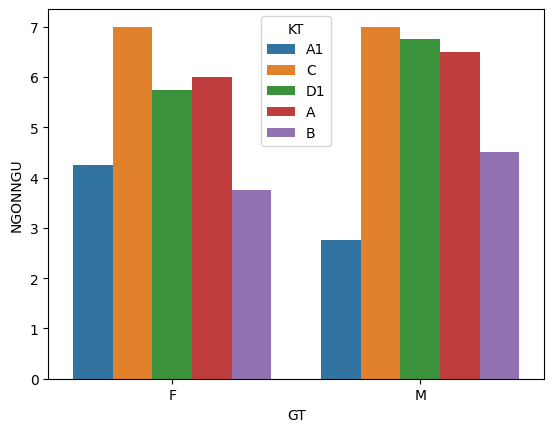

In [27]:
''' 
So sánh điểm cao nhất của NGONNGU theo nhóm GT theo KT 
Lưu ý: không để estimator thì mặc định là mean 
estimator: count, min max sum std, mean (default) 
''' 
sns.barplot(x='GT',y='NGONNGU',hue='KT',data=df,errorbar=None,estimator=max) 
plt.show() 

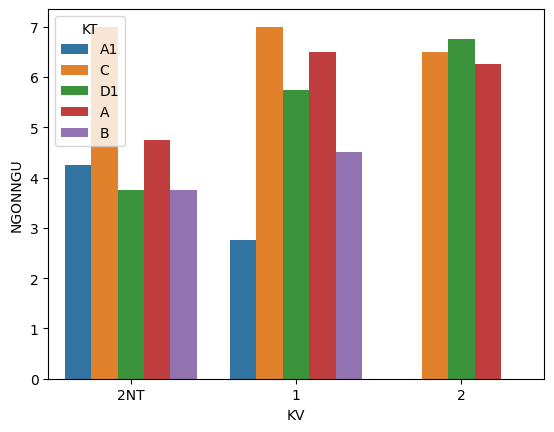

In [28]:
''' 
Khi biến định tính dùng làm nhóm tổng hợp có nhiều hơn 2 giá trị thì ta cần dùng hàm 
tổng hợp thông qua thư viện numpy 
''' 
sns.barplot(x='KV',y='NGONNGU',hue='KT',data=df,errorbar=None,estimator=np.max) 
plt.show()

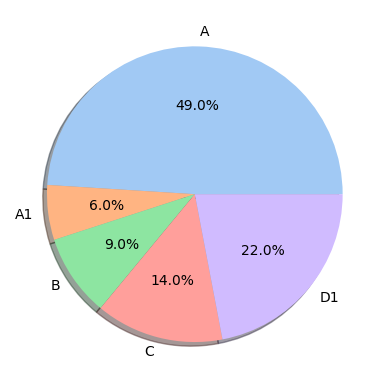

In [29]:
''' 
Lưu ý:  - Với biến định tính thì ta chỉ có 1 hàm tổng hợp là hàm COUNT, MODE - Với định lượng thì ta có thể sử dụng các hàm tổng hợp như: COUNT, MAX, MIN, 
MEAN, MEDIAN, MODE, SUM, STD 
''' 
 
''' 
Biểu đồ PIE 
Mục đích: Trực quan dữ liệu theo nhóm tỉ lệ phần trăm 
''' 
gb = df.groupby(['KT'])['KT'].agg(['count']) 
# group by trên nhóm khối thi trên biến khối thi và dùng hàm count
''' 
Biểu đồ PIE 
Mục đích: Trực quan dữ liệu theo nhóm tỉ lệ phần trăm 
''' 
gb = df.groupby(['KT'])['KT'].agg(['count']) 
# group by trên nhóm khối thi trên biến khối thi và dùng hàm count 
labels = gb.index 
data = list(gb['count']) 
colors = sns.color_palette('pastel') # tạo bảng màu 
plt.pie(data,labels=labels,colors=colors,autopct='%1.1f%%',shadow=True) 
plt.show()

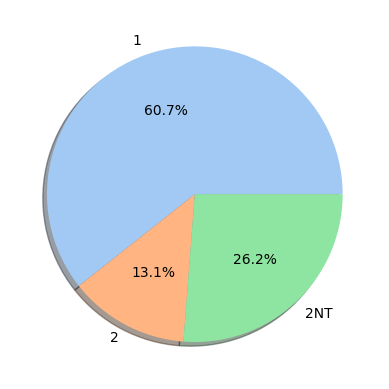

In [30]:
''' 
Trực quan tỉ lệ % tổng điểm CONG trên từng nhóm khu vực 
# coi khu vực nào dc cộng điểm nhiều nhất 
''' 
gb = df.groupby(['KV'])['CONG'].agg(['sum']) 
labels = gb.index 
data = list(gb['sum']) 
colors = sns.color_palette('pastel') # tạo bảng màu 
plt.pie(data,labels=labels,colors=colors,autopct='%1.1f%%',shadow=True) 
plt.show()

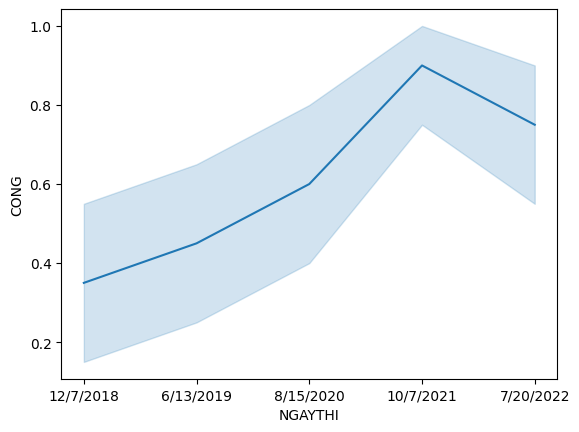

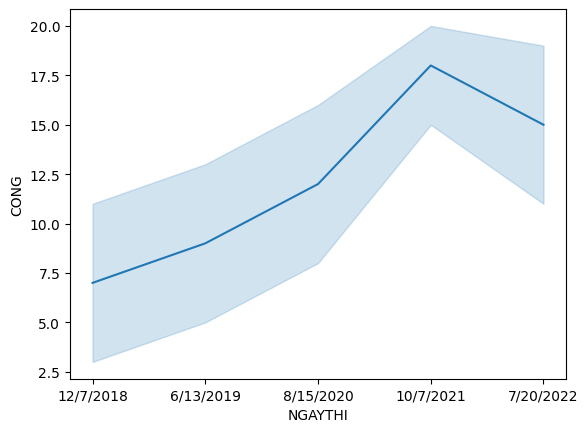

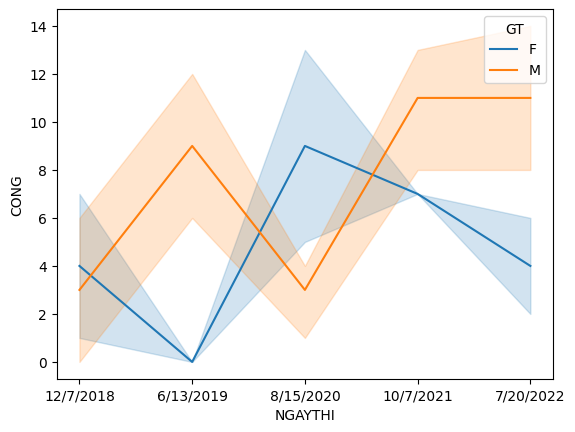

In [31]:
''' 
KHi trực quan dữ liệu ta cần lưu ý đến loại biến đang tham gia vào trực quan 
Thông thường việc chọn lựa biểu đồ sẽ căn cứ dựa trên ý nghĩa nghiệp vụ và sự phối hợp 
giữa các loại biến như: - Định tính kết hợp định tính - Định tính kết hợp định lượng - Định lượng kết hợp định lượng 
''' 
 
''' 
Biểu đồ line thường dùng để tổng hợp dữ liệu theo trục "Thời gian" hoặc "có thứ tự" 
Ví dụ: tổng hợp trung bình điểm cộng theo các năm thi '''
sns.lineplot(x='NGAYTHI',y='CONG',data=df) 
plt.show() 
 
# Trực quan dữ liệu tổng điểm CONG dựa theo năm bằng biểu đồ line 
sns.lineplot(x='NGAYTHI',y='CONG',data=df,estimator=sum) 
plt.show() 
 
# tổng hợp tổng điểm cộng theo các năm thitrên từng nhóm giới tính bằng biểu đồ line 
sns.lineplot(x='NGAYTHI',y='CONG',hue='GT',data=df,estimator=sum) 
plt.show()

In [32]:
''' 
Buổi 3 
Bước 1: mô tả biến định lượng 
''' 
df['NGONNGU'].describe() 
# Giải thích ý nghĩa các đại lượng 
# Độ lệch chuẩn (std) bằng căn bậc 2 giá trị phương sai, độ lệch chuẩn và phương sai thể 
# hiện mức độ biến thiên, biến động 
# sự đa dạng của tập dữ liệu số. Độ lệch chuẩn càng cao thì tập dữ liệu biến động mạnh 
# => mức độ đa dạng nhiều và ngược lại thì tập dữ liệu sẽ ổn định hơn 
# Tứ phân vị 
# Q1 : 25% -> Có 25% dữ liệu nhỏ hơn giá trị Q1 
# Q2: 50% (median trung vị) -> giá trị này cho biết có 50% sv nhỏ hơn Q2 và lớn hơn Q2 
# Q3: 75% -> có 25% số lượng lớn hơn Q3 
# Q1 - Q3 là khoảng IQR: khoảng mà các dữ liệu được diễn ra dc coi là thông thường 
# (50%) 
 
df[['NGONNGU','LOGIC','UNG XU']].describe()

,NGONNGU,LOGIC,UNG XU
count,100.000000,100.000000,100.000000
mean,3.740000,4.255000,4.875000
std,1.424408,1.060053,1.041136
min,1.000000,1.500000,2.750000
25%,2.500000,3.500000,4.250000
50%,3.625000,4.125000,4.750000
75%,4.750000,4.750000,5.500000
max,7.000000,8.000000,8.000000


In [33]:
''' 
CV = std/mean (Confficient of variant) 
So sánh mức độ ổn định của điểm số  
''' 
cvNN = df['NGONNGU'].std()/df['NGONNGU'].mean()
cvLogic = df['LOGIC'].std()/df['LOGIC'].mean() 
cvUngXu = df['UNG XU'].std()/df['UNG XU'].mean() 
print('cvNN: ', cvNN) 
print('cvLogic: ', cvLogic) 
print('cvUngXu: ', cvUngXu) 
# 
df[['NGONNGU','LOGIC','UNG XU']].std()/df[['NGONNGU','LOGIC','UNG XU']].mean() 
 
df.groupby('GT')[['NGONNGU','LOGIC','UNG XU']].describe() 

cvNN:  0.3808578707188297
cvLogic:  0.2491311130540305
cvUngXu:  0.2135664058628459


NGONNGU                                                   LOGIC            \
     count      mean       std   min     25%   50%  75%  max count      mean   
GT                                                                             
F     48.0  3.854167  1.348594  1.25  3.1875  3.75  5.0  7.0  48.0  4.046875   
M     52.0  3.634615  1.496288  1.00  2.4375  3.50  4.5  7.0  52.0  4.447115   

    ...            UNG XU                                                      
    ...  75%   max  count      mean       std   min     25%    50%  75%   max  
GT  ...                                                                        
F   ...  4.5  6.75   48.0  4.906250  0.946192  3.25  4.2500  4.875  5.5  7.25  
M   ...  5.0  8.00   52.0  4.846154  1.130194  2.75  4.1875  4.625  5.5  8.00  

[2 rows x 24 columns]

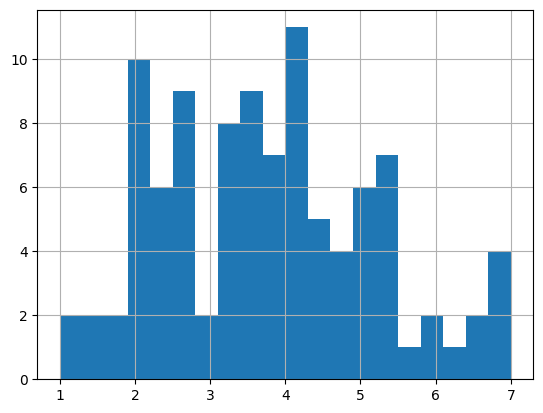

In [34]:
''' 
Histogram cho biết xác suất xảy ra của biến cố trong khoảng giá trị dữ liệu nào nhiều 
nhất 
''' 
df['NGONNGU'].hist(bins=20) 
plt.show()

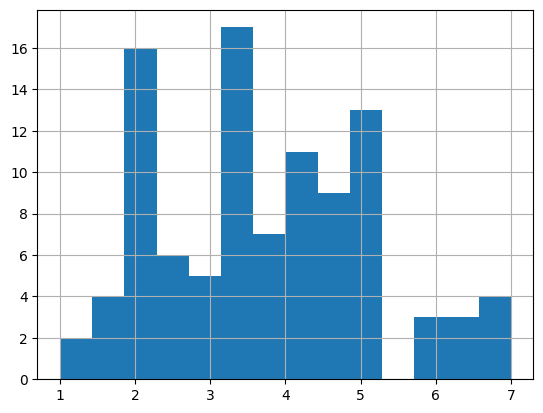

In [35]:
# Hướng dẫn khi vẽ bins trong histogram 
# Lưu ý: khi số lượng bins khác nhau sẽ dẫn đến hình dạng của histogram khác nhau 
df['NGONNGU'].hist(bins=14) 
plt.show()

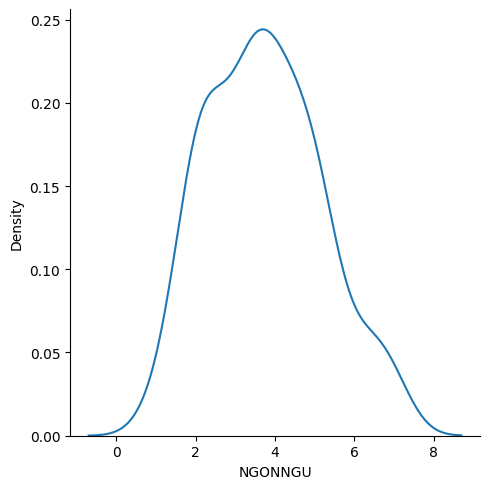

In [36]:
''' 
Nâng cao hơn histogram thì ra khám phá dạng phân phối xác xuất 
Làm mịn với phân phối xác xuất 
''' 
sns.displot(df,x='NGONNGU',kind='kde') 
plt.show() 

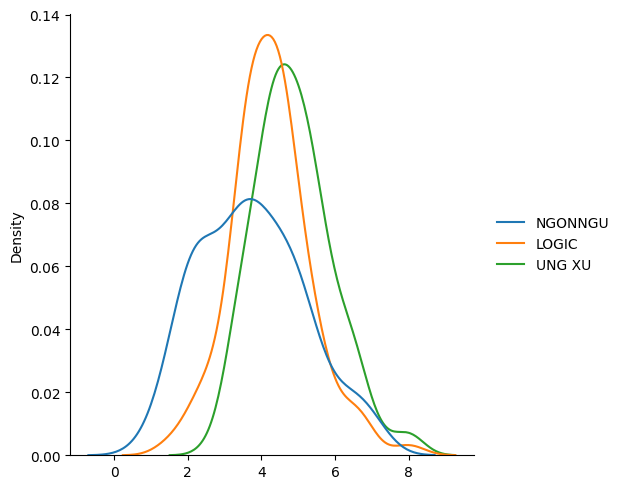

In [38]:
sns.displot(data= df[['NGONNGU','LOGIC','UNG XU']],kind='kde') 
plt.show() 
# Hãy cho biết phân phối của biến số nào gần với phân phối chuẩn hơn => logic với ứng 
# xử

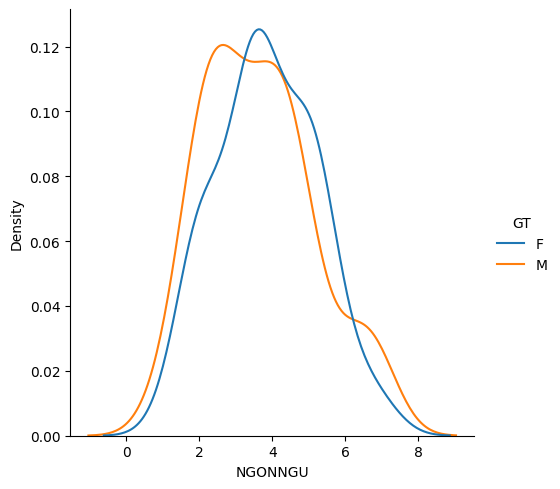

In [39]:
sns.displot(df,x='NGONNGU',hue='GT',kind='kde') 
plt.show() 
# Câu hỏi: nhóm giới tính nào gần hơn: F gần hơn 

lower bound =  1.625
upper bound =  6.625
IQR 1.25
ngoai bien dưới -0.25
ngoai bien tren 8.5


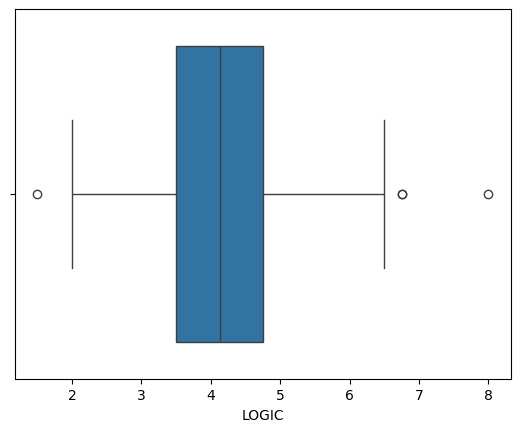

In [40]:
''' 
Đây là biểu đồ quan trọng trong việc phân tích dữ liệu định lượng 
Biểu đồ này cung cấp các thông tin quan trọng như 
1. Q1: Tứ phân vị 25% 
2. Q2: Tứ phân vị 50% (median) 
3. Q3: Tứ phân vị 75% 
4. Độ lớn IQR = |Q3-Q1| 
5. Lower bound: Q1 - 1.5*IQR 
6. Upper bound = Q3 + 1.5*IQR 
7. Các ngoại biên, bất thường (outlier) cần xử lý trong dữ liệu 
Outlier: là điểm dữ liệu khác biệt quá nheièu so với đa số 
Hướng dẫn 
    + Tính khoảng nghi ngờ chứa outliers 
    + Tính khoảng chắc chắn chứa outliers 
''' 
sns.boxplot(data=df['LOGIC'],orient="h") 
print('lower bound = ', df['LOGIC'].quantile(0.25) - 1.5*(df['LOGIC'].quantile(0.75) - 
df['LOGIC'].quantile(0.25))) 
print('upper bound = ', df['LOGIC'].quantile(0.75) + 1.5*(df['LOGIC'].quantile(0.75) - 
df['LOGIC'].quantile(0.25))) 
IQR = df['LOGIC'].quantile(0.75) - df['LOGIC'].quantile(0.25) 
print('IQR',IQR) 
print('ngoai bien dưới', 1.625  -1.5*IQR) 
print('ngoai bien tren', 6.625  +1.5*IQR)

<Axes: >

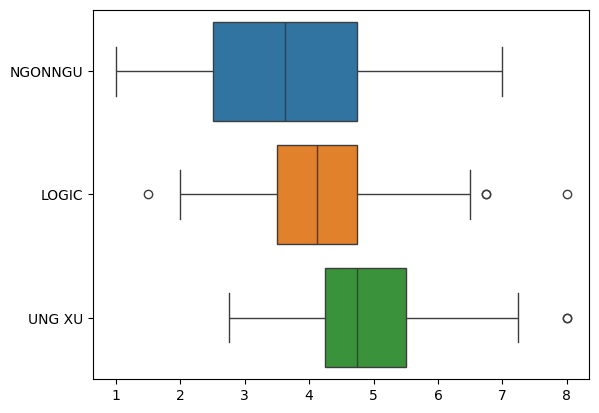

In [42]:
# Tính khoảng giá trị nghi ngờ bất thường 
# Tính khoảng giá trị được cho là bất thường 
# Tính xem có bao nhiêu sinh vien có điểm thi là bất thường 
sns.boxplot(data=df[['NGONNGU','LOGIC',"UNG XU"]],orient='h')

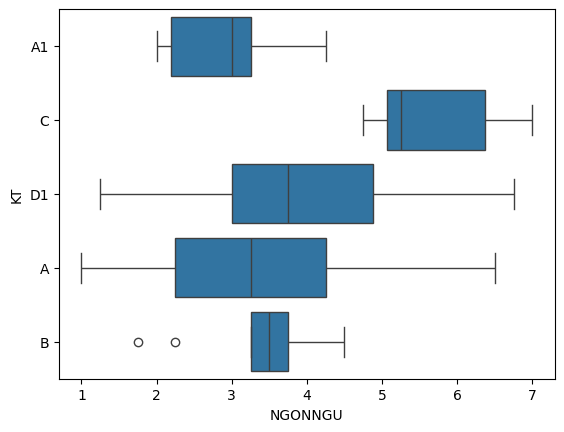

In [43]:
# Hãy cho biết điểm số môn nào không xảy ra bất thường => NGONNGU 
sns.boxplot(x='NGONNGU',y='KT',data=df,orient='h') 
plt.show() 

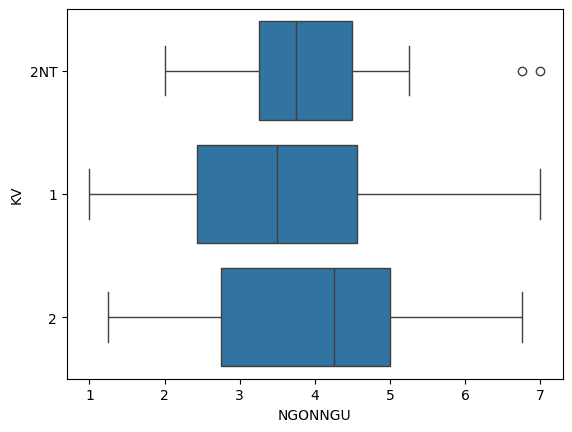

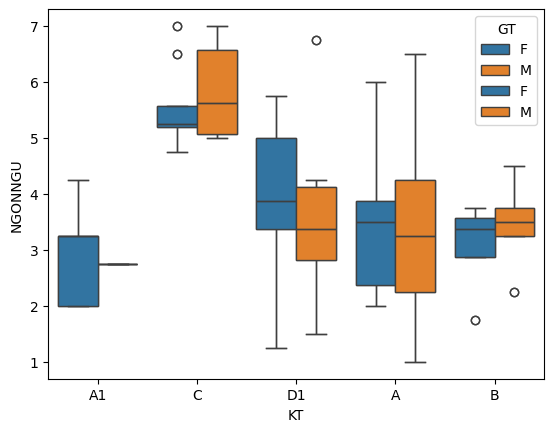

In [44]:
sns.boxplot(x='NGONNGU',y='KV',data=df,orient='h') 
plt.show() 

 
sns.boxplot(x='KT',y='NGONNGU',hue='GT',data=df) 
plt.show() 
# câu hỏi: xác định các biểu đồ bất thường 
# Khối A1 không đủ dữ liệu để vẽ 

In [46]:
''' 
Skewess = độ xiên, độ lớn (trị tuyệt đối) cho biết mức độ dữ liệu lệch nhiều hay ít so với 
đường công phân phối chuẩn 
Cho biết xác xuất được phân bổ lệch về phía nào nhiều 
Trị tuyệt đối giá trị càng lớn thì dữ liệu phân phối nghiên càng nhiều (lệch) 
Diễn giải cho skewness 
skewnes > 0 tức là mean > median: ta gọi là positive skewness 
hay lệch phải, tức là giá trị ngoại biên outliers nhận giá trị lớn sẽ đẩy giá trị trung bình về 
phía cuối 
skewnes < 0 tức là mean < median: ta gọi là negative skewness hay lệch trái, tức là giá tị 
outliers nhận giá trị nhỏ sẽ đẩy giá trị trung  
bình về phía đầu 
skewness = 0 tức là mean = median = mode: phân phối không lệch còn được gọi là phân 
phối đối xứng 
''' 
df['NGONNGU'].skew() 
''' 
Note: Khi ptich dữ liệu với các phương pháp có liên quan phân phối chuẩn thì cần kiểm 
tra skewness 
nếu dl quá lệch so với phân phối chuẩn thì ta cần điều chỉnh bằng các hàm transform cho 
bớt lệch 
đặc biệt là phân tích hồi quy'''
df[['NGONNGU','LOGIC','UNG XU']].skew() 
''' 
Kurtosis: Độ nhọn, trị tuyệt đối cho biết mức độ nhọn của phân phối 
Độ lớn của kurtosis càng gần 3 thì fit 
Dưới 3 thì fat 
Trên 3 thì thin 
 
Thông thường để đánh giá hình dáng độ nhọn ta dùng đại lượng excess kurtosis (theo 
Pearson) - 3 
+ NẾu excess > 0 -> thin 
+ Nếu excess = 0 -> fit 
+ Nếu excess < 0 -> fat 
Trong pandas sử dụng Fisher's Kutorsis tức là đã chuẩn hóa giá trị về excess kutorsis theo 
mean = 0 
+ Trị tuyệt đối excess kutorsis càng cao thì mức độ thin, fat càng lớn 
Lưu ý : với phân phối chuẩn thì excess kurtosis = 0, skewness = 0  
''' 
df[['NGONNGU']].kurtosis()

NGONNGU   -0.517004
dtype: float64

In [48]:
# Câu hỏi: biến ngôn ngữ có độ nhọn như thế nào  
# Trả lời là: fat 
 
df[['NGONNGU','LOGIC','UNG XU']].kurtosis()

NGONNGU   -0.517004
LOGIC      1.372439
UNG XU     0.442173
dtype: float64

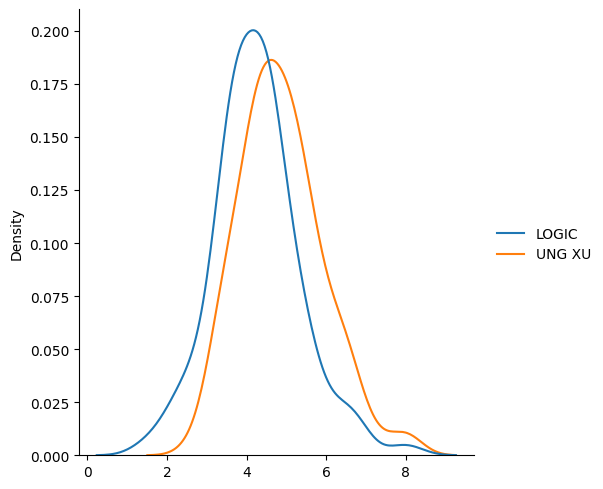

In [50]:
sns.displot(data=df[['LOGIC','UNG XU']],kind='kde') 
plt.show() 
# Nhìn biểu đồ cho biết ý nghĩa kutorsis cho LOGIC UNGXU

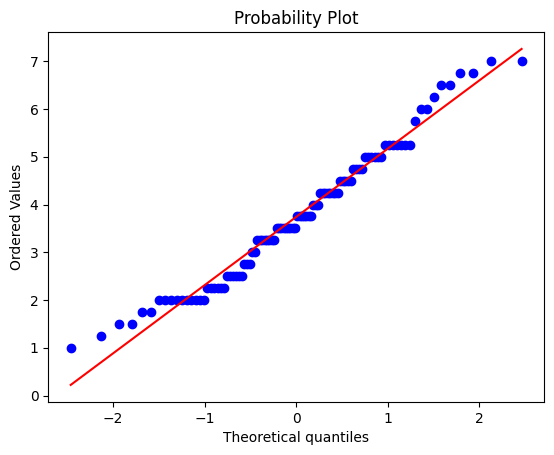

In [51]:
''' 
Kiểm định phân phối chuẩn 
''' 
from scipy import stats 
stats.probplot(df['NGONNGU'],plot=sns.mpl.pyplot) 
plt.show() 


In [52]:
# không có phân phối chuẩn
''' 
Phân tích sự tác động (ảnh hưởng) qua lại giữa 2 biến định lượng 
''' 
''' 
Buổi 3:  
Hiệp phương sai: co-variance  
Giá trị co-variance > 0 thì 2 biến có tương quan thuận (đồng biến) 
Giá trị co-variance < 0 thì 2 biến có tương quan nghịch (nghịch biến) 
Độ lớn (trị tuyệt đối của giá trị) càng lớn thì mức độ quan hệ (tương quan) càng chặt chẽ 
 
Ma trận hiệp phương sai: co-variance matrix 
''' 
df[['T5','T6']].cov()

,T5,T6
T5,2.184658,1.568961
T6,1.568961,1.858314


In [53]:
# So sánh mức độ tương quan giữa T5 so với LOGIC và T6 so với LOGIC 
df[['T5','T6','LOGIC']].cov() 

,T5,T6,LOGIC
T5,2.184658,1.568961,0.289308
T6,1.568961,1.858314,0.435672
LOGIC,0.289308,0.435672,1.123712


In [54]:
''' 
Với phương pháp so sánh tương quan bằng co-variance thì ta không đo lường được 
cường độ  
tương quan giữa 2 biến định lượng. 
Pearson Correlation: tương quan tuyến tính 
r nằm trong khoảng [-1,1] 
r = 0 => Không tương quan 
r < 0: Tương quan nghịch 
r > 0: tương quan thuận 
|r| (độ lớn) càng gần 1 thì tương quan càng cao 
|r| < 0.5 thì tương quan thấp 
    [0.5,0.65]: Khá 
    [0.65,0.75]: Tốt 
    [0.75,0.9]: Rất tốt 
    > 0.9: hoàn hảo 
Ma trận tương quan: correlation matrix
Lưu ý: được sử dụng khảo sát tương quan tuyến tính nhằm phân tích mối quan hệ tuyến 
tính giữa 2 biến định lượng 
''' 
df[['T5','T6']].corr()

,T5,T6
T5,1.000000,0.778683
T6,0.778683,1.000000


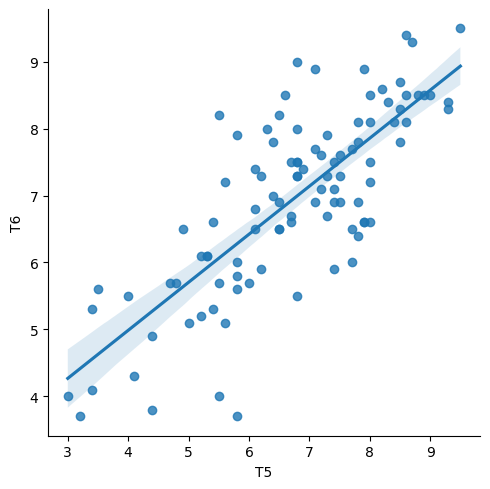

In [55]:
''' 
Trực quan hóa tương quan tuyến tính giữa 2 biến định lượng 
Khám phá tương quan tuyến tính của 2 biến định lượng 
thông qua biểu đồ phân tán (scatter)  
''' 
sns.lmplot(data=df, x='T5',y='T6', fit_reg=True) 
plt.show()

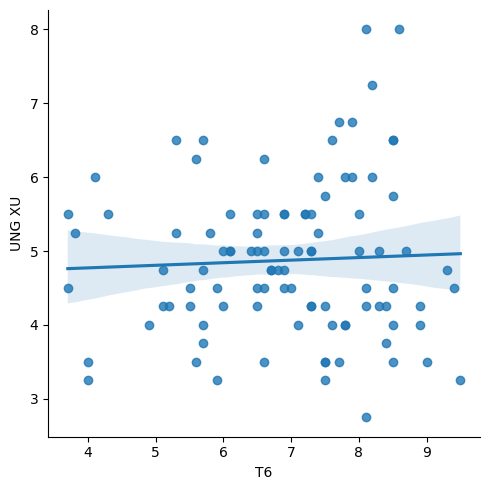

In [56]:
# Sinh viên tự khám phá độ tương quan giữa biến T6 và UNGXU 
df[['T6','UNG XU']].corr() 
sns.lmplot(data=df, x='T6',y='UNG XU', fit_reg=True) 
plt.show()

In [58]:
df[['T6','UNG XU']].corr() 

,T6,UNG XU
T6,1.000000,0.045638
UNG XU,0.045638,1.000000


In [60]:
df[['T6','UNG XU','NGONNGU','LOGIC','UNG XU']].corr() 

,T6,UNG XU,NGONNGU,LOGIC,UNG XU
T6,1.000000,0.045638,-0.033360,0.301490,0.045638
UNG XU,0.045638,1.000000,0.018731,-0.091523,1.000000
NGONNGU,-0.033360,0.018731,1.000000,0.035154,0.018731
LOGIC,0.301490,-0.091523,0.035154,1.000000,-0.091523
UNG XU,0.045638,1.000000,0.018731,-0.091523,1.000000


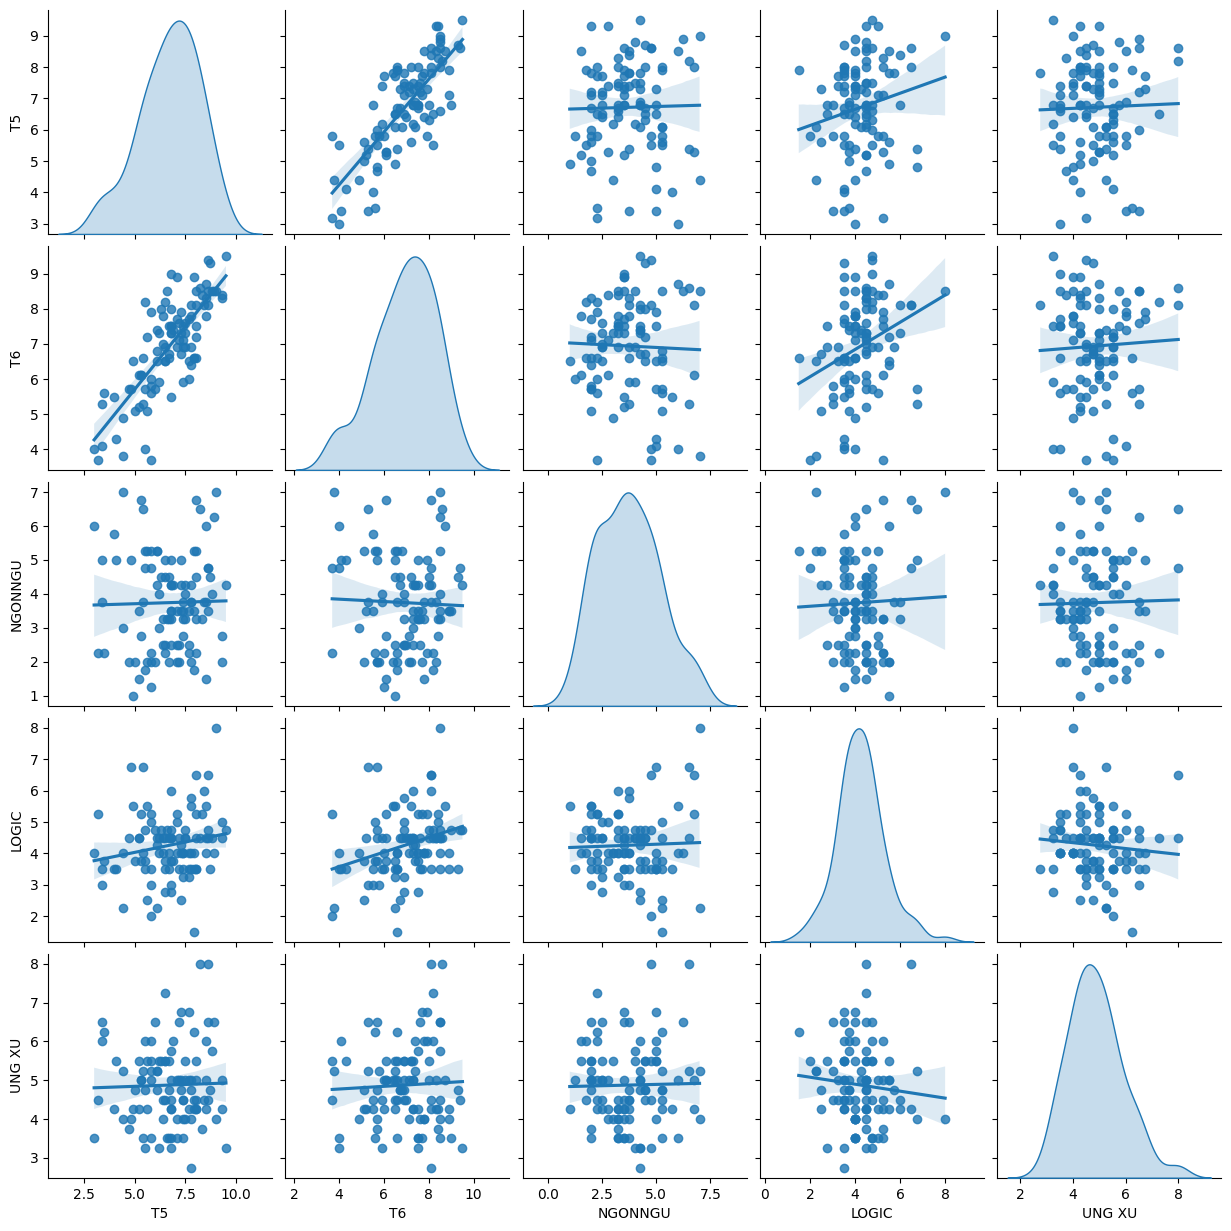

In [62]:
# Biểu đồ tổng hợp khám phá tổng hợp nhiều biến định lượng  
sns.pairplot(df[['T5','T6','NGONNGU','LOGIC','UNG XU']], diag_kind='kde',kind='reg') 
plt.show() 

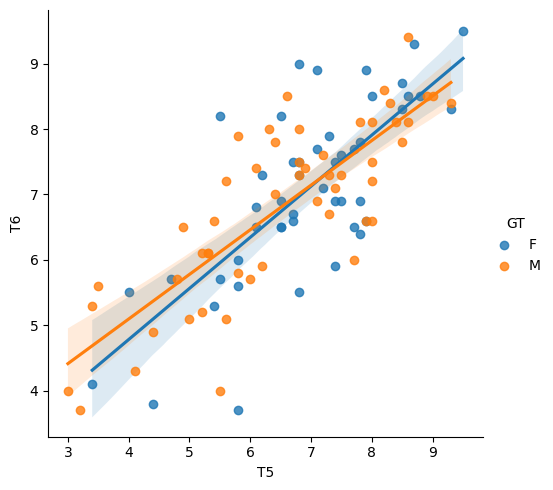

In [63]:
# Trực quan tương quan tuyến tính theo nhóm (định tính) giữa 2 biến định lượng 
sns.lmplot(data=df,x='T5',y='T6',hue='GT',fit_reg=True) 
plt.show() 